# Lifting the GLPR Self-Attention Particle System into the $L^2_W$ Framework

1. **Self-Attention as Interaction-Energy Gradient Flow** — the (USA) surrogate model on $S^{d-1}$
2. **3D-PCA Sphere Visualization** — token clustering across $L^2_W$ realisations
3. **Propagation of Chaos in $L^2_W$** — Grönwall bound vs $n$ and $\beta$
4. **Fréchet Mean and Variance** — cluster-location uncertainty across realisations
5. **Uncertainty Regularisation** — shrinkage of the Transformer output
6. **Bayesian Transformer Consistency** — posterior flow tracks oracle flow

**Key equations:**
- SA model (GLPR §2.2): $\dot x_i = P^\perp_{x_i}\!\left(\frac{\sum_j e^{\beta\langle x_i,x_j\rangle}x_j}{\sum_k e^{\beta\langle x_i,x_k\rangle}}\right)$
- USA model (Wasserstein gradient flow of $E_\beta$, GLPR §3.3): $\dot x_i = P^\perp_{x_i}\!\left(\tfrac{1}{n}\sum_j e^{\beta\langle x_i,x_j\rangle}x_j\right)$
- Interaction energy: $E_\beta[\mu] = \tfrac{1}{2\beta}\iint e^{\beta\langle x,x'\rangle}\,d\mu(x)\,d\mu(x')$
- $L^2_W$ metric: $d(\xi,\eta) = \bigl(\mathbb{E}_\omega[W_2^2(\xi(\omega),\eta(\omega))]\bigr)^{1/2}$

**Install:** `pip install POT scipy numpy matplotlib scikit-learn tqdm`
""")

# ─────────────────────────────────────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────────────────────────────────────

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import logsumexp
from sklearn.decomposition import PCA
import ot
from tqdm import tqdm

plt.rcParams.update({
    'figure.facecolor': '#FFFFFF', 'axes.facecolor': '#FFFFFF',
    'font.family': 'serif', 'mathtext.fontset': 'cm',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 12, 'figure.dpi': 110,
})

rng = np.random.default_rng(13)

VIRIDIS = plt.cm.viridis(np.linspace(0.1, 0.85, 8))
PLASMA  = plt.cm.plasma(np.linspace(0.1, 0.85, 8))
print("Setup complete.")

Setup complete.


## 1. Self-Attention Particle Dynamics on $S^{d-1}$

The SA/USA models define a forward-Euler interacting particle system on $S^{d-1}$.
The $L^2_W$ framework treats the empirical measure
$\hat\mu^n(0)=\frac{1}{n}\sum_i\delta_{x_i(0)}$, with $x_i(0)\overset{\rm iid}{\sim}\mu_0$,
as a **random element of $L^2_W(S^{d-1})$** (§4.1).
Each particle trajectory $\omega\mapsto M_t(\omega)$ is a **sample path** of the lifted gradient flow.


In [37]:
# ── Tangent-space projection ─────────────────────────────────────────────────
def proj_tangent(X, V):
    """P^perp_x V = V - <V,x>x  for each row.  X, V: (n, d)."""
    return V - (V * X).sum(axis=1, keepdims=True) * X


# ── Single Euler step ────────────────────────────────────────────────────────
def sa_step(X, dt, beta, model='SA'):
    """
    One forward-Euler step for SA or USA dynamics on S^{d-1}.
    Returns updated X re-normalised to the sphere.
    """
    logits = beta * (X @ X.T)
    if model == 'USA':
        # USA: Wasserstein gradient flow of E_beta (no softmax denominator)
        weights = np.exp(logits) / X.shape[0]
    else:
        # SA: true self-attention with softmax
        weights = np.exp(logits - logsumexp(logits, axis=1, keepdims=True))
    V    = weights @ X
    proj = proj_tangent(X, V)
    X_new = X + dt * proj
    return X_new / np.linalg.norm(X_new, axis=1, keepdims=True)


# ── Full trajectory simulation ───────────────────────────────────────────────
def simulate_sa(X0, T, dt, beta, model='SA', save_every=1):
    """
    Returns
    -------
    traj    : (T_saved, n, d)
    energies: (n_steps,) interaction energy at every step
    ts      : (T_saved,) time grid
    """
    n_steps = int(round(T / dt))
    X = X0.copy()
    traj, energies = [X.copy()], []
    n = X.shape[0]
    for step in range(n_steps):
        X = sa_step(X, dt, beta, model)
        E = np.sum(np.exp(beta * (X @ X.T))) / (2.0 * beta * n**2)
        energies.append(E)
        if (step + 1) % save_every == 0:
            traj.append(X.copy())
    ts = np.linspace(0, T, len(traj))
    return np.array(traj), np.array(energies), ts


def sample_sphere(n, d, rng_):
    """Uniform sample on S^{d-1}."""
    X = rng_.standard_normal((n, d))
    return X / np.linalg.norm(X, axis=1, keepdims=True)


def sw2(X, Y, n_proj=50):
    """Sliced W_2 between two equal-weight point clouds."""
    return ot.sliced_wasserstein_distance(X, Y, n_projections=n_proj, seed=0)

print("Core dynamics functions defined.")


Core dynamics functions defined.



# ─────────────────────────────────────────────────────────────────────────────
# INTERACTION ENERGY
# ─────────────────────────────────────────────────────────────────────────────

## 2. Interaction Energy $E_\beta$ as a Lyapunov Function

GLPR Lemma 3.7 shows
$$\frac{d}{dt}E_\beta[\mu_t] = \int\!\!\left\|\nabla(G_\beta*\mu_t)(x)\right\|^2 d\mu_t(x) \ge 0$$
along the (USA) flow. $E_\beta$ is a **Lyapunov functional for the lifted flow**:
each sample path $\omega$ increases its interaction energy, but from a different starting value.

The spread of energy paths across realisations is captured by the
**Fréchet variance** of $E_\beta(M_t)$ ( Definition 3.25).

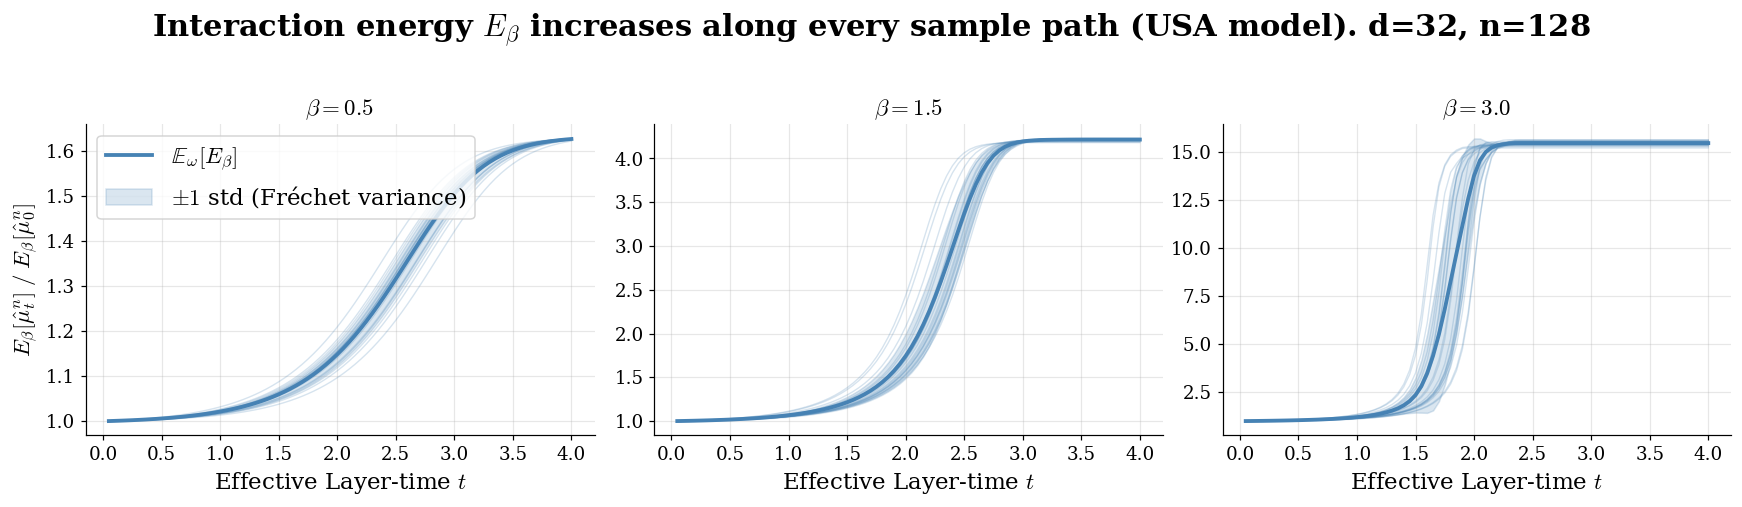

In [44]:
d_lyap   = 32
n_tokens = 128
T_lyap   = 4.0
dt_lyap  = 0.05
n_omega  = 20
betas_ly = [0.5, 1.5, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, beta in zip(axes, betas_ly):
    all_en = []
    for r in range(n_omega):
        X0 = sample_sphere(n_tokens, d_lyap, rng)
        _, en_r, _ = simulate_sa(X0, T_lyap, dt_lyap, beta, model='USA')
        all_en.append(en_r / en_r[0])   # normalise to E_0 = 1

    all_en = np.array(all_en)
    ts_e   = np.linspace(dt_lyap, T_lyap, all_en.shape[1])

    for r in range(n_omega):
        ax.plot(ts_e, all_en[r], color='steelblue', alpha=0.22, lw=0.9)

    mean_e = all_en.mean(axis=0)
    std_e  = all_en.std(axis=0)
    ax.plot(ts_e, mean_e, color='steelblue', lw=2.5,
            label=r'$\mathbb{E}_\omega[E_\beta]$')
    ax.fill_between(ts_e, mean_e - std_e, mean_e + std_e,
                    color='steelblue', alpha=0.2,
                    label=r'$\pm 1$ std (Fréchet variance)')

    fv = float(np.var(all_en[:, -1]))
    ax.set_title(fr'$\beta = {beta}$ ',
                 fontsize=15, weight='bold')
    
    ax.set_xlabel('Effective Layer-time $t$', fontsize=15)
    if ax == axes[0]:
        ax.set_ylabel(r'$E_\beta[\hat\mu^n_t]\;/\;E_\beta[\hat\mu^n_0]$', fontsize=15)
    if beta == betas_ly[0]:
        ax.legend(fontsize=15)
    ax.grid(alpha=0.3)

plt.suptitle(
    r'Interaction energy $E_\beta$ increases along every sample path (USA model). '
    f'd={d_lyap}, n={n_tokens}',
    fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_energy_lyapunov.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# PCA SPHERE VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

## 3. Token Clustering on $S^2$ via 3D-PCA

We run SA dynamics with $d=15$ tokens on $S^{14}$, collect trajectories across
multiple $L^2_W$ **realisations** $M_0(\omega)$ (different i.i.d. draws from $\mu_0$),
then project to 3D via shared PCA and normalise to $S^2$.

**Reading the figure:**  Each row is one realisation $\omega$.  Columns are time snapshots.
Tokens start spread over the sphere and progressively collapse.
Crucially, the **cluster location $x^*(\omega)$** differs per realisation —
this is the **random Dirac mass** $M_\infty(\omega)=\delta_{x^*(\omega)}$ predicted by GLPR+.

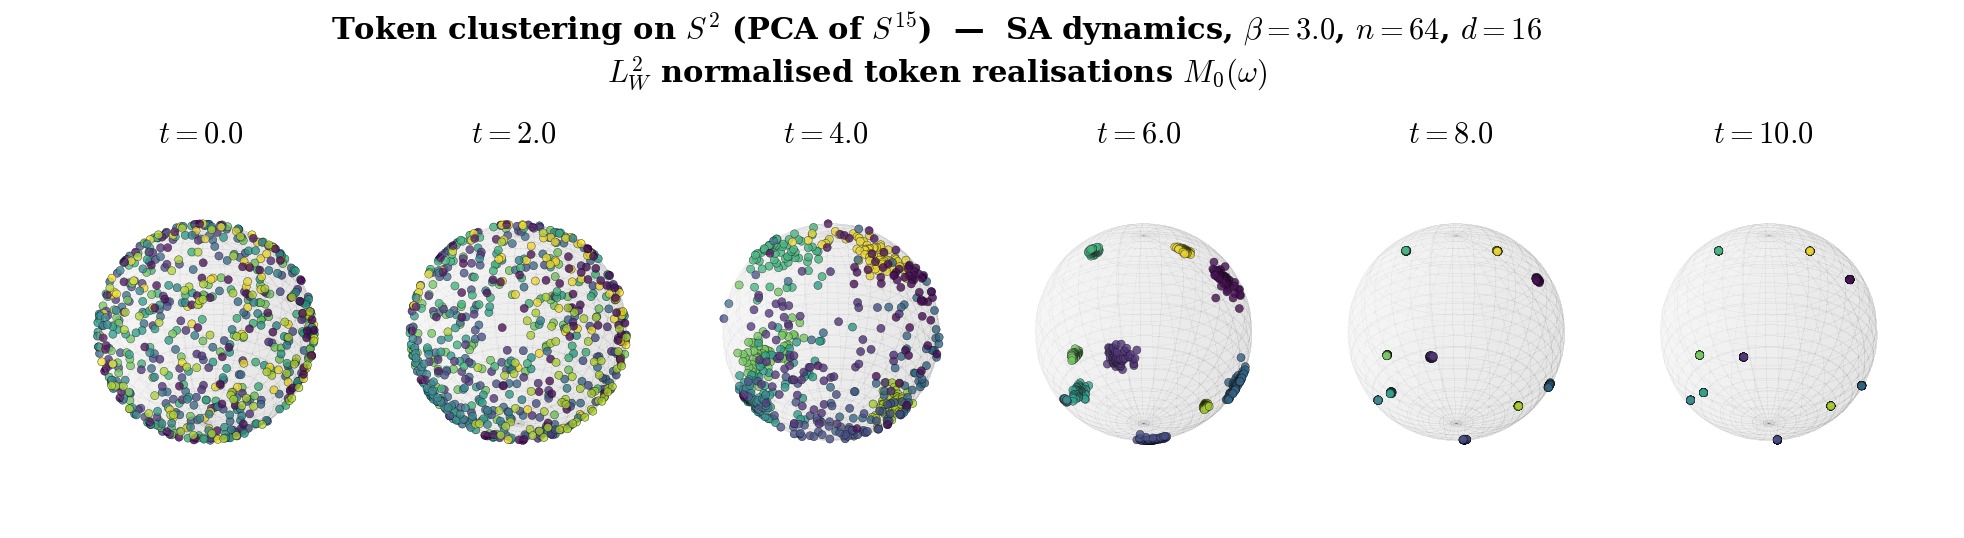

In [39]:
d_pca     = 16
n_tok_pca = 64
T_pca     = 10
dt_pca    = 0.05
beta_pca  = 3.0
n_real    = 10
snap_ts   = np.linspace(0, T_pca, 6)  # timepoints to snapshot for PCA projection
save_ev_pca = max(1, int(round(0.5 / dt_pca)))

# Simulate all realisations
all_trajs = []
for r in range(n_real):
    X0 = sample_sphere(n_tok_pca, d_pca, rng)
    traj_r, _, _ = simulate_sa(X0, T_pca, dt_pca, beta_pca,
                                model='SA', save_every=save_ev_pca)
    all_trajs.append(traj_r)

ts_pca = np.linspace(0, T_pca, all_trajs[0].shape[0])

# Fit shared PCA on all initial tokens (gives a common coordinate system)
X0_all = np.vstack([t[0] for t in all_trajs])
pca    = PCA(n_components=3).fit(X0_all)
evr    = pca.explained_variance_ratio_


def project_s2(X, pca_):
    P = pca_.transform(X)
    return P / np.linalg.norm(P, axis=1, keepdims=True)


snap_idxs = [int(np.argmin(np.abs(ts_pca - t))) for t in snap_ts]
real_cols  = plt.cm.tab10(np.linspace(0, 0.4, n_real))


def draw_sphere_bg(ax, alpha=0.07, col='#CCCCCC'):
    u = np.linspace(0, 2*np.pi, 60)
    v = np.linspace(0, np.pi, 60)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color=col, alpha=alpha,
                    linewidth=0, antialiased=False)
    for lat in np.linspace(-np.pi/2, np.pi/2, 8):
        cl = np.cos(lat)
        ax.plot(cl*np.cos(u), cl*np.sin(u),
                np.full_like(u, np.sin(lat)), col, lw=0.3, alpha=0.35)
    for lon in np.linspace(0, np.pi, 5):
        ax.plot(np.cos(lon)*np.sin(v), np.sin(lon)*np.sin(v),
                np.cos(v), col, lw=0.3, alpha=0.35)


fig_pca = plt.figure(figsize=(5.5 * len(snap_ts), 5.0))
gs = gridspec.GridSpec(1, len(snap_ts), hspace=0.05, wspace=-0.75, top=0.8)

# Generate viridis colors for the number of realisations
viridis_cols = plt.cm.viridis(np.linspace(0, 1, n_real))


for c, (t_snap, s_idx) in enumerate(zip(snap_ts, snap_idxs)):
    ax = fig_pca.add_subplot(gs[0, c], projection='3d')
    draw_sphere_bg(ax)

    # Loop through each realization and plot on the SAME sphere for this timepoint
    for r in range(n_real):
        pts = project_s2(all_trajs[r][s_idx], pca)
        ax.scatter(pts[:,0], pts[:,1], pts[:,2],
                   c=[viridis_cols[r]], s=28, alpha=0.8,
                   edgecolors='k', linewidths=0.3, zorder=5,
                   label=fr'$\omega_{r+1}$' if c == 0 else "")

    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
    ax.set_box_aspect([1,1,1])
    ax.set_axis_off()
    ax.set_title(f'$t={t_snap:.1f}$', fontsize=20, weight='bold', pad=4)

fig_pca.suptitle(
    fr'Token clustering on $S^2$ (PCA of $S^{{{d_pca-1}}}$)  —  '
    fr'SA dynamics, $\beta={beta_pca}$, $n={n_tok_pca}$, $d={d_pca}$' + '\n'
    r'$L^2_W$ normalised token realisations $M_0(\omega)$',
    fontsize=20, weight='bold', y=1.05)

plt.savefig('fig2_pca_sphere_clustering.png', bbox_inches='tight', dpi=130)
plt.show()

In [40]:
import matplotlib.animation as animation

# --- GIF Configuration ---
# interval: Delay between frames in milliseconds (e.g., 200ms = 5 frames per second)
# fps: You can also calculate interval as 1000/fps
gif_speed_interval = 100
output_filename = "clustering_evolution.gif"

def update(frame_idx):
    """Update function for the animation"""
    ax.clear()
    draw_sphere_bg(ax)
    
    t_val = ts_pca[frame_idx]
    
    # Plot all realizations for the current time frame
    for r in range(n_real):
        pts = project_s2(all_trajs[r][frame_idx], pca)
        ax.scatter(pts[:,0], pts[:,1], pts[:,2],
                   c=[viridis_cols[r]], s=40, alpha=0.8,
                   edgecolors='k', linewidths=0.3, zorder=5)
    
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.set_title(f'Evolution of Clusters | $t={t_val:.2f}$', 
                 fontsize=14, weight='bold')

# Setup the figure for animation
fig_anim = plt.figure(figsize=(7, 7))
ax = fig_anim.add_subplot(111, projection='3d')

# Create the animation object
# We use every frame saved in all_trajs
total_frames = all_trajs[0].shape[0]
ani = animation.FuncAnimation(
    fig_anim, update, frames=range(total_frames), 
    interval=gif_speed_interval
)

# Save the GIF
# Note: This requires 'pillow' or 'imagemagick' installed (pip install pillow)
print(f"Saving GIF to {output_filename}...")
ani.save(output_filename, writer='pillow')
plt.close(fig_anim)
print("Done!")

Saving GIF to clustering_evolution.gif...
Done!



# ─────────────────────────────────────────────────────────────────────────────
# PROPAGATION OF CHAOS
# ─────────────────────────────────────────────────────────────────────────────
## 4. Propagation of Chaos in $L^2_W$

Combining  Proposition 4.22 (Grönwall) with the SA Lipschitz constant $L\propto\beta$:
$$\sup_{t\in[0,T]} d^2(\hat\mu^n_t, \mu_t) \;\leq\; e^{2LT}\,d^2(\hat\mu^n_0, \mu_0)
\;\leq\; C\,e^{2LT}\,r(n,d)$$
where $r(n,d)$ is the Fournier–Guillin rate ( Theorem 4.3).

**Two competing effects:**
- More tokens ($n\uparrow$): smaller initial error $d(\hat\mu^n_0,\mu_0)$
- Larger $\beta$: larger $L$ → exponential amplification of initial error

The panels show sliced-$W_2$ between empirical ($n$ tokens) and oracle ($N=512$) flows
for two inverse temperatures, illustrating the early-time convergence and the
**late-time divergence** as realisations cluster to different locations.

100%|██████████| 3/3 [00:33<00:00, 11.32s/it]


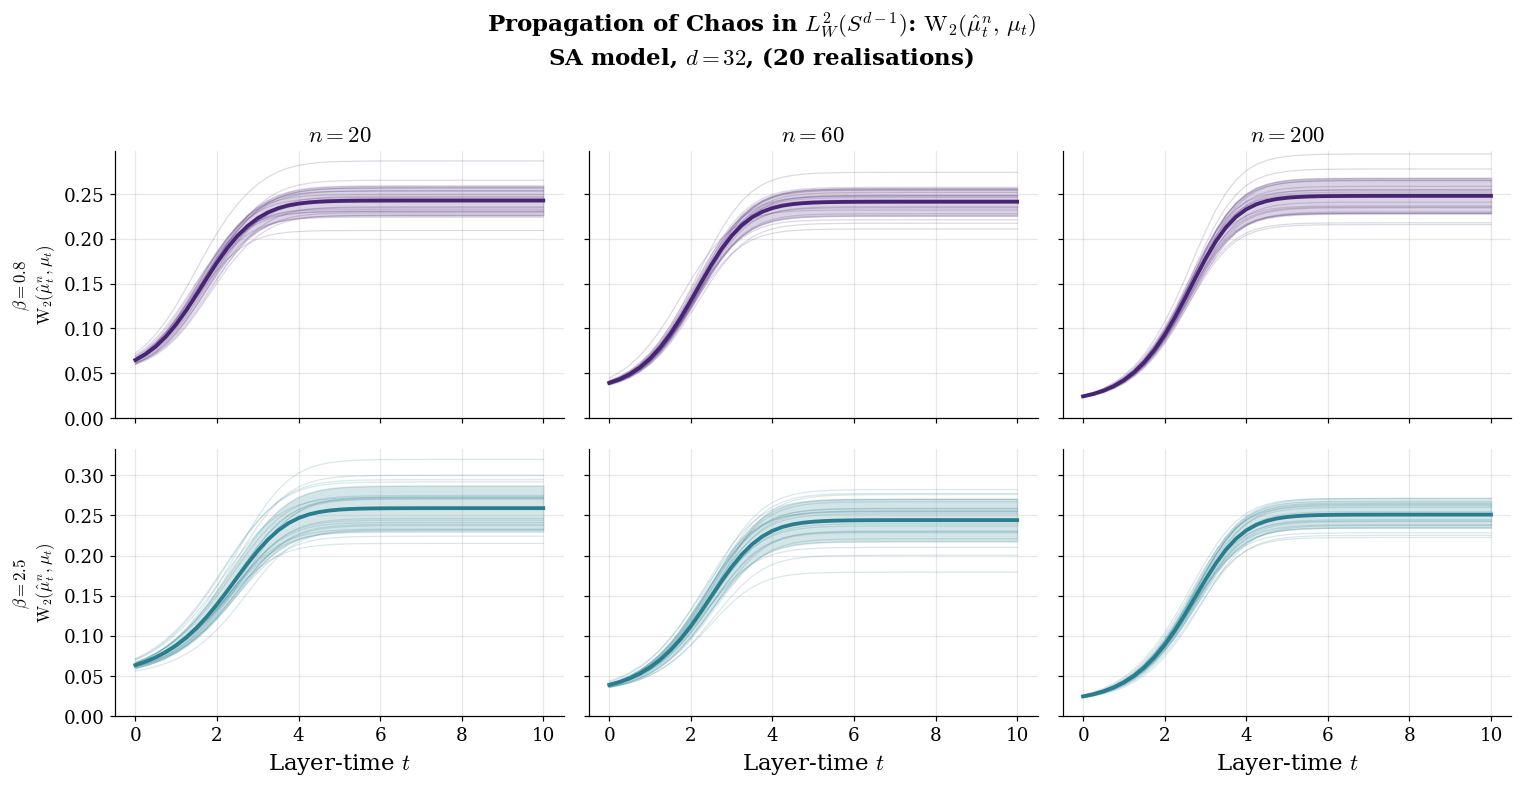

In [41]:
d_poc      = 32
n_pop_poc  = 512
n_emp_list = [20, 60, 200]
betas_poc  = [0.8, 2.5]
T_poc      = 10.0
dt_poc     = 0.05
n_omega_poc = 20
n_proj_sw   = 100
save_ev_poc = max(1, int(round(0.25 / dt_poc)))

fig_poc, axes_poc = plt.subplots(
    len(betas_poc), len(n_emp_list),
    figsize=(14, 7), sharex=True, sharey='row')

for row, beta in enumerate(betas_poc):
    # Oracle: one large-n run
    X0_pop = sample_sphere(n_pop_poc, d_poc, rng)
    traj_pop, _, ts_poc = simulate_sa(X0_pop, T_poc, dt_poc, beta,
                                       model='SA', save_every=save_ev_poc)

    for col, n_emp in enumerate(tqdm(n_emp_list)):
        ax = axes_poc[row, col]
        sw_mat = np.zeros((n_omega_poc, len(ts_poc)))

        for r in range(n_omega_poc):
            X0e = sample_sphere(n_emp, d_poc, rng)
            traj_e, _, _ = simulate_sa(X0e, T_poc, dt_poc, beta,
                                        model='SA', save_every=save_ev_poc)
            for ti in range(len(ts_poc)):
                sw_mat[r, ti] = sw2(traj_pop[ti], traj_e[ti], n_proj=n_proj_sw)

        sw_mean = sw_mat.mean(axis=0)
        sw_std  = sw_mat.std(axis=0)

        for r in range(n_omega_poc):
            ax.plot(ts_poc, sw_mat[r], alpha=0.18, lw=0.8,
                    color=VIRIDIS[row * 3])

        ax.plot(ts_poc, sw_mean, lw=2.5, color=VIRIDIS[row * 3])
        ax.fill_between(ts_poc, np.maximum(sw_mean - sw_std, 0),
                        sw_mean + sw_std,
                        alpha=0.2, color=VIRIDIS[row * 3])

        if row == 0:
            ax.set_title(f'$n = {n_emp}$', fontsize=15, weight='bold')
        if col == 0:
            ax.set_ylabel(
                fr'$\beta={beta}$' + '\n' + r'$\mathrm{W}_2(\hat\mu^n_t,\mu_t)$',
                fontsize=11)
        if row == len(betas_poc) - 1:
            ax.set_xlabel('Layer-time $t$', fontsize=15)
        ax.grid(alpha=0.3)
        ax.set_ylim(bottom=0)

fig_poc.suptitle(
    r'Propagation of Chaos in $L^2_W(S^{d-1})$: '
    r'$\mathrm{W}_2(\hat\mu^n_t,\,\mu_t)$' + '\n'
    fr'SA model, $d={d_poc}$, ({n_omega_poc} realisations)',
    fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_propagation_of_chaos.png', bbox_inches='tight')
plt.show()



# ─────────────────────────────────────────────────────────────────────────────
# BAYESIAN TRANSFORMER
# ─────────────────────────────────────────────────────────────────────────────

## 5. Bayesian Transformer Consistency ( §5 + GLPR)

**Model:**  tokens $x_1,\ldots,x_n \overset{\rm iid}{\sim} \mathrm{vMF}(\mu_0,\kappa_0)$
(tokens concentrated near the *true* direction $\mu_0\in S^{d-1}$).

**Prior:** uncertainty about $\mu_0$ is modelled by a distribution over directions;
each realisation $\Pi(\omega)=\mathrm{vMF}(\mu^\omega,\kappa_0)$ for $\mu^\omega$ drawn from the prior.

**Posterior:** after observing $n_{\rm obs}$ data tokens,
the posterior mean direction $\hat\mu_n=\mathrm{normalise}(\tau\mu_{\rm prior}+\kappa_0\sum_i x_i)$
concentrates near $\mu_0$ as $n_{\rm obs}\to\infty$ (conjugate vMF update).

**Proposition 5.8** predicts: for large $n_{\rm obs}$,
the SA flow initialised at the posterior draw tracks the oracle flow (initialised at the
true distribution) uniformly over all layers.

In [42]:
def sample_vmf(n, mu, kappa, rng_):
    """Sample from vMF(mu, kappa) via normalised Gaussian approximation."""
    d  = len(mu)
    X  = rng_.multivariate_normal(kappa * mu, np.eye(d), size=n)
    return X / np.linalg.norm(X, axis=1, keepdims=True)


def posterior_vmf_dir(X_obs, mu_prior, tau_prior, kappa_like):
    """Conjugate posterior mean direction for vMF likelihood."""
    nat  = tau_prior * mu_prior + kappa_like * X_obs.sum(axis=0)
    conc = np.linalg.norm(nat)
    return nat / (conc + 1e-10), conc


d_bay       = 5
beta_bay    = 2.5
T_bay       = 5.0
dt_bay      = 0.05
n_toks_bay  = 40
kappa_0     = 3.0
tau_prior   = 0.5
n_omega_bay = 15
n_obs_list  = [5, 20, 200, 2000]
save_ev_bay = max(1, int(round(0.5 / dt_bay)))

mu_true  = sample_sphere(1, d_bay, rng)[0]
mu_prior = sample_sphere(1, d_bay, rng)[0]

# Oracle flow (large n from true distribution)
X0_oracle  = sample_vmf(500, mu_true, kappa_0, rng)
traj_ora, _, ts_bay = simulate_sa(X0_oracle, T_bay, dt_bay, beta_bay,
                                   model='SA', save_every=save_ev_bay)

sw_bay = {}
for n_obs in tqdm(n_obs_list, desc='n_obs'):
    X_data = sample_vmf(n_obs, mu_true, kappa_0, rng)
    mu_post, conc_post = posterior_vmf_dir(X_data, mu_prior, tau_prior, kappa_0)
    sw_mat = np.zeros((n_omega_bay, len(ts_bay)))
    for r in range(n_omega_bay):
        mu_r  = sample_vmf(1, mu_post, conc_post, rng)[0]
        X0_r  = sample_vmf(n_toks_bay, mu_r, kappa_0, rng)
        tr_r, _, _ = simulate_sa(X0_r, T_bay, dt_bay, beta_bay,
                                  model='SA', save_every=save_ev_bay)
        for ti in range(len(ts_bay)):
            sw_mat[r, ti] = sw2(traj_ora[ti], tr_r[ti], n_proj=50)
    sw_bay[n_obs] = sw_mat
print("Bayesian simulation complete.")


n_obs: 100%|██████████| 4/4 [00:02<00:00,  1.39it/s]

Bayesian simulation complete.


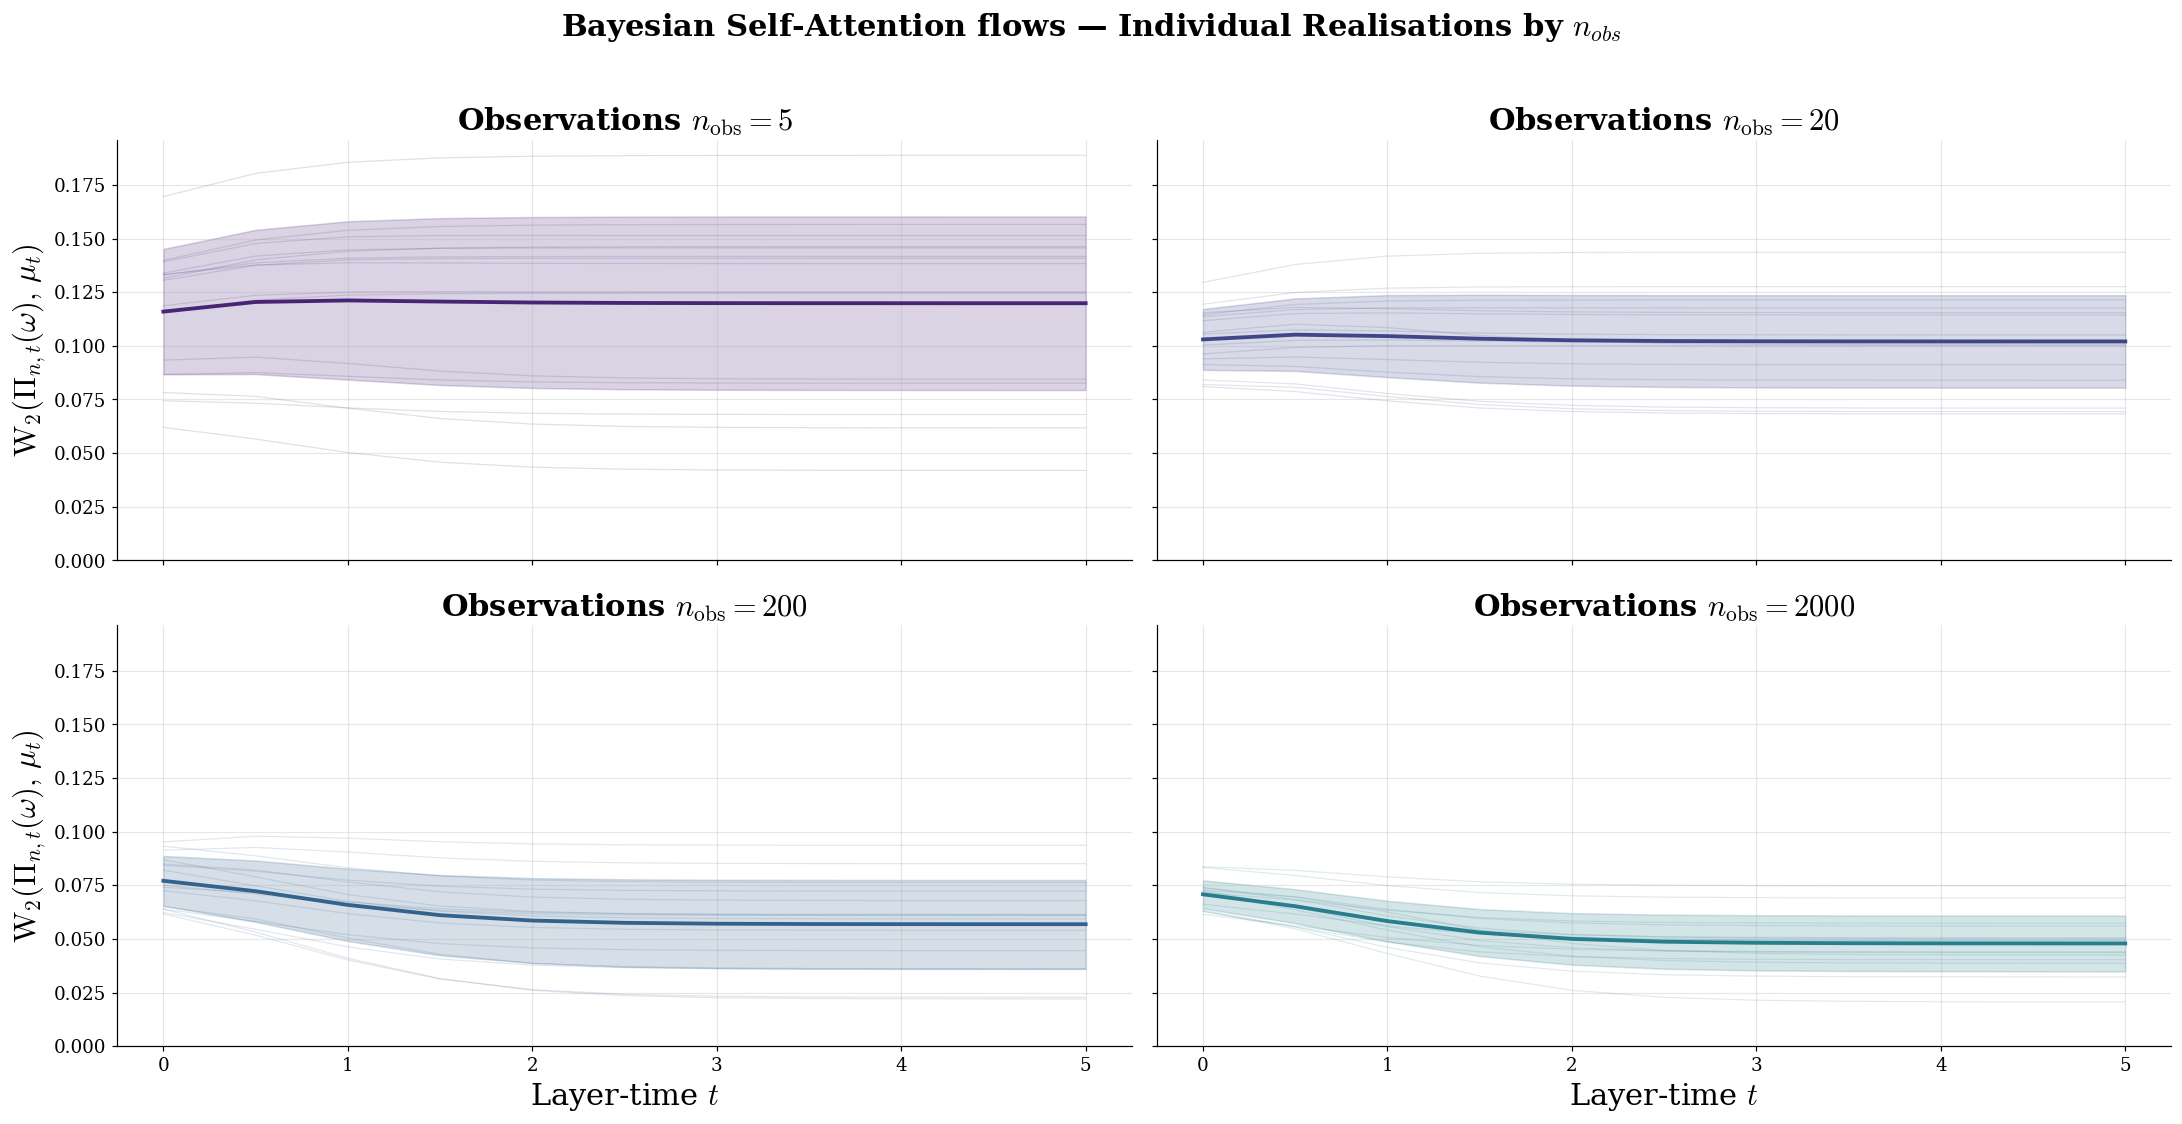

In [43]:
# Split individual realisations into a 2x2 grid
fig_grid, axes_grid = plt.subplots(2, 2, figsize=(20, 10), sharex=True, sharey=True)
axes_flat = axes_grid.flatten()
colors_bay = VIRIDIS[:len(n_obs_list)]

for i, (n_obs, col) in enumerate(zip(n_obs_list, colors_bay)):
    ax = axes_flat[i]
    sw = sw_bay[n_obs]
    sm, ss = sw.mean(0), sw.std(0)
    
    # Plot individual realisations
    for r in range(n_omega_bay):
        ax.plot(ts_bay, sw[r], color=col, alpha=0.15, lw=0.8)
    
    # Plot mean and variance
    ax.plot(ts_bay, sm, color=col, lw=2.5, label=fr'$n_{{\rm obs}}={n_obs}$')
    ax.fill_between(ts_bay, np.maximum(sm - ss, 0), sm + ss,
                     color=col, alpha=0.2)
    
    ax.set_title(fr'Observations $n_{{\rm obs}}={n_obs}$', fontsize=20, weight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)
    if i >= 2: ax.set_xlabel('Layer-time $t$', fontsize=20)
    if i % 2 == 0: ax.set_ylabel(r'$\mathrm{W}_2(\Pi_{n,t}(\omega),\,\mu_t)$', fontsize=20)

fig_grid.suptitle('Bayesian Self-Attention flows — Individual Realisations by $n_{obs}$', 
                  fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_bayesian_sa_individuals.png', bbox_inches='tight')
plt.show()